In [ ]:
import subprocess, sys, os, json, math, time, warnings, random, tempfile
warnings.filterwarnings("ignore")

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "huggingface_hub>=0.34.0", "pyarrow>=15.0", "av>=12.0",
                "pandas", "matplotlib", "tqdm"], check=False)

import numpy as np, pandas as pd, pyarrow as pa, pyarrow.parquet as pq
import matplotlib.pyplot as plt
from huggingface_hub import HfApi, HfFileSystem, hf_hub_download, hf_hub_url
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

REPO_ID      = "nvidia/Cosmos3-DROID"
ROOT         = "success"
VIDEO_KEY    = "observation.image.wrist_image_left"
FPS          = 15

N_EPISODES   = 48
HORIZON      = 8
OBS_HISTORY  = 2
USE_VISION   = True
N_VIS_EPS    = 6
VIS_SIZE     = 96
EPOCHS       = 12
BATCH        = 256
SEED         = 0

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[env] torch={torch.__version__}  device={DEV}")

if os.environ.get("HF_TOKEN"):
    from huggingface_hub import login; login(os.environ["HF_TOKEN"])

api = HfApi()
fs  = HfFileSystem()
HFS = lambda rel: f"datasets/{REPO_ID}/{rel}"
URL = lambda rel: hf_hub_url(REPO_ID, rel, repo_type="dataset")

print("\n" + "="*78 + "\n1. REPO INTROSPECTION\n" + "="*78)
all_files = api.list_repo_files(REPO_ID, repo_type="dataset")
print(f"total files in repo : {len(all_files):,}")
for prefix in ("success/data", "success/videos", "success/meta",
               "failure/data", "failure/videos", "failure/meta"):
    print(f"  {prefix:<18} {sum(f.startswith(prefix) for f in all_files):>6,} files")

data_shards = sorted(f for f in all_files if f.startswith(f"{ROOT}/data/") and f.endswith(".parquet"))
vid_shards  = sorted(f for f in all_files if f.startswith(f"{ROOT}/videos/{VIDEO_KEY}/"))
meta_files  = sorted(f for f in all_files if f.startswith(f"{ROOT}/meta/"))
print(f"\n[{ROOT}] data shards={len(data_shards)}  video shards({VIDEO_KEY})={len(vid_shards)}")
print("first data shard :", data_shards[0])
print("first video shard:", vid_shards[0])

print("\n" + "="*78 + "\n2. METADATA\n" + "="*78)
info = json.load(open(hf_hub_download(REPO_ID, f"{ROOT}/meta/info.json", repo_type="dataset")))
print(f"episodes={info.get('total_episodes'):,}  frames={info.get('total_frames'):,}  "
      f"tasks={info.get('total_tasks'):,}  fps={info.get('fps')}")
print("data_path template :", info.get("data_path"))
print("video_path template:", info.get("video_path"))

FEATURES = info["features"]
state_keys  = sorted(k for k in FEATURES if k.startswith("observation.state"))
action_keys = sorted(k for k in FEATURES if k.startswith("action."))
video_keys  = sorted(k for k in FEATURES if FEATURES[k]["dtype"] == "video")
print("\nstate  :", [f"{k.split('.')[-1]}{tuple(FEATURES[k]['shape'])}" for k in state_keys])
print("action :", [f"{k.split('.')[-1]}{tuple(FEATURES[k]['shape'])}" for k in action_keys])
print("video  :", video_keys)

tdf = pd.read_parquet(hf_hub_download(REPO_ID, f"{ROOT}/meta/tasks.parquet", repo_type="dataset"))
tdf = tdf.reset_index()
tcol = "task" if "task" in tdf.columns else tdf.columns[0]
TASKS = dict(zip(tdf["task_index"].astype(int), tdf[tcol].astype(str))) if "task_index" in tdf \
        else {i: str(v) for i, v in enumerate(tdf[tcol])}
print(f"\n{len(TASKS):,} task strings. Random sample:")
for t in random.sample(list(TASKS.values()), min(8, len(TASKS))): print("   ·", t[:90])

ep_files = [f for f in meta_files if "/episodes/" in f and f.endswith(".parquet")]
eps = pd.concat([pd.read_parquet(hf_hub_download(REPO_ID, f, repo_type="dataset"))
                 for f in ep_files[:4]], ignore_index=True)
print(f"\nepisodes table: {len(eps):,} rows")
print("columns:", [c for c in eps.columns if not c.startswith("stats")][:14], "...")
print(eps[[c for c in ("episode_index", "length", "data/chunk_index", "data/file_index")
           if c in eps.columns]].head())

In [ ]:
print("\n" + "="*78 + "\n3. BYTE-RANGE PARQUET READER\n" + "="*78)

def open_pf(rel_path):
    return pq.ParquetFile(fs.open(HFS(rel_path), "rb"))

def rowgroup_span(pf):
    md, starts, c = pf.metadata, [], 0
    for i in range(md.num_row_groups):
        starts.append(c); c += md.row_group(i).num_rows
    return np.array(starts), c

def read_rows(pf, lo, hi, columns):
    starts, total = rowgroup_span(pf)
    ends = np.append(starts[1:], total)
    rgs  = [i for i in range(len(starts)) if starts[i] < hi and ends[i] > lo]
    tbl  = pf.read_row_groups(rgs, columns=columns)
    return tbl.slice(lo - starts[rgs[0]], hi - lo)

def col2np(tbl, name):
    ca = tbl.column(name).combine_chunks()
    if pa.types.is_list(ca.type) or pa.types.is_large_list(ca.type) or pa.types.is_fixed_size_list(ca.type):
        flat = np.asarray(ca.flatten().to_numpy(zero_copy_only=False))
        return flat.reshape(len(ca), -1).astype(np.float32)
    return np.asarray(ca.to_numpy(zero_copy_only=False)).reshape(-1, 1).astype(np.float32)

SHARD = data_shards[0]
pf    = open_pf(SHARD)
md    = pf.metadata
print(f"shard        : {SHARD}")
print(f"rows         : {md.num_rows:,}   row_groups: {md.num_row_groups}   "
      f"compressed: {md.serialized_size/1e6:.1f} MB footer")
print(f"columns      : {len(pf.schema_arrow.names)}")

t0 = time.time()
ep_idx_all = pf.read(columns=["episode_index"]).column("episode_index").to_numpy()
print(f"pulled episode_index column ({len(ep_idx_all):,} rows) in {time.time()-t0:.1f}s")

uniq, first_pos = np.unique(ep_idx_all, return_index=True)
order      = np.argsort(first_pos)
uniq       = uniq[order]; first_pos = first_pos[order]
last_pos   = np.append(first_pos[1:], len(ep_idx_all))
EP_BOUNDS  = {int(e): (int(a), int(b)) for e, a, b in zip(uniq, first_pos, last_pos)}
print(f"{len(EP_BOUNDS)} episodes live in this shard "
      f"(ids {uniq.min()}..{uniq.max()}, mean len {np.mean(last_pos-first_pos):.0f} frames)")

STATE_USE  = ["observation.state.joint_positions", "observation.state.gripper_position",
              "observation.state.cartesian_position"]
ACTION_USE = ["action.joint_velocity", "action.gripper_position"]
READ_COLS  = STATE_USE + ACTION_USE + ["timestamp", "frame_index", "task_index", "episode_index"]

def load_episode(ep):
    lo, hi = EP_BOUNDS[ep]
    tbl = read_rows(pf, lo, hi, READ_COLS)
    out = {k: col2np(tbl, k) for k in STATE_USE + ACTION_USE}
    out["timestamp"]  = col2np(tbl, "timestamp").ravel()
    out["task_index"] = int(col2np(tbl, "task_index").ravel()[0])
    out["task"]       = TASKS.get(out["task_index"], "<unknown>")
    out["state"]      = np.concatenate([out[k] for k in STATE_USE], axis=1)
    out["action"]     = np.concatenate([out[k] for k in ACTION_USE], axis=1)
    return out

EP0 = int(uniq[0]); traj = load_episode(EP0)
print(f"\nepisode {EP0}: T={len(traj['state'])}  state_dim={traj['state'].shape[1]}  "
      f"action_dim={traj['action'].shape[1]}")
print(f"task: {traj['task']!r}")

print("\n" + "="*78 + "\n5. TRAJECTORY ANALYTICS\n" + "="*78)
q    = traj["observation.state.joint_positions"]
grip = traj["observation.state.gripper_position"].ravel()
cart = traj["observation.state.cartesian_position"]
dq   = traj["action.joint_velocity"]
t    = traj["timestamp"]

fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(2, 3, 1)
for j in range(q.shape[1]): ax.plot(t, q[:, j], lw=1.1, label=f"j{j+1}")
ax.set_title("joint positions [rad]"); ax.set_xlabel("s"); ax.legend(fontsize=6, ncol=2)

ax = fig.add_subplot(2, 3, 2)
ax.plot(t, grip, color="crimson", lw=1.4)
opens = np.where(np.abs(np.diff(grip)) > 0.05)[0]
for k in opens[:40]: ax.axvline(t[k], color="k", alpha=.15, lw=.8)
ax.set_title(f"gripper (|Δ|>0.05 events: {len(opens)})"); ax.set_xlabel("s")

ax = fig.add_subplot(2, 3, 3, projection="3d")
ax.plot(cart[:, 0], cart[:, 1], cart[:, 2], lw=1.2)
ax.scatter(*cart[0, :3], c="g", s=45, label="start"); ax.scatter(*cart[-1, :3], c="r", s=45, label="end")
ax.set_title("EE cartesian path [m]"); ax.legend(fontsize=7)

ax = fig.add_subplot(2, 3, 4)
im = ax.imshow(dq.T, aspect="auto", cmap="RdBu_r", vmin=-np.abs(dq).max(), vmax=np.abs(dq).max())
ax.set_title("action.joint_velocity (7 x T)"); ax.set_ylabel("joint"); plt.colorbar(im, ax=ax)

ax = fig.add_subplot(2, 3, 5)
freqs = np.fft.rfftfreq(len(dq), d=1/FPS)
for j in range(dq.shape[1]):
    ax.semilogy(freqs, np.abs(np.fft.rfft(dq[:, j] - dq[:, j].mean())) + 1e-9, lw=.9)
ax.set_title("action spectra (Nyquist=7.5 Hz)"); ax.set_xlabel("Hz")

ax = fig.add_subplot(2, 3, 6)
lens = [EP_BOUNDS[e][1] - EP_BOUNDS[e][0] for e in list(EP_BOUNDS)[:2000]]
ax.hist(np.array(lens)/FPS, bins=40, color="steelblue")
ax.set_title(f"episode duration [s] (n={len(lens)})"); ax.set_xlabel("s")
plt.suptitle(f"{REPO_ID} · {ROOT} · ep {EP0} · {traj['task'][:70]}", y=1.0)
plt.tight_layout(); plt.show()

In [ ]:
print("\n" + "="*78 + "\n6. VIDEO: SEEK-BASED AV1 DECODE (no full download)\n" + "="*78)

def video_window(ep):
    row = eps.loc[eps["episode_index"] == ep]
    if len(row) == 0: return None
    row = row.iloc[0]
    ci = int(row.get(f"videos/{VIDEO_KEY}/chunk_index", row.get("data/chunk_index", 0)))
    fi = int(row.get(f"videos/{VIDEO_KEY}/file_index",  row.get("data/file_index", 0)))
    f0 = float(row.get(f"videos/{VIDEO_KEY}/from_timestamp", 0.0))
    f1 = float(row.get(f"videos/{VIDEO_KEY}/to_timestamp",
                       f0 + int(row.get("length", 100))/FPS))
    return f"{ROOT}/videos/{VIDEO_KEY}/chunk-{ci:03d}/file-{fi:03d}.mp4", f0, f1

def decode_pyav(url, t0, t1, max_frames, stride, size):
    import av
    c = av.open(url, options={"rw_timeout": "30000000"})
    s = c.streams.video[0]; s.thread_type = "AUTO"
    if t0 > 0: c.seek(int(t0 / s.time_base), stream=s)
    out, k = [], 0
    for fr in c.decode(s):
        ts = float(fr.pts * s.time_base)
        if ts < t0 - 1e-3: continue
        if ts > t1 + 1e-3 or len(out) >= max_frames: break
        if k % stride == 0:
            out.append(fr.reformat(width=size, height=size, format="rgb24").to_ndarray())
        k += 1
    c.close()
    return np.stack(out) if out else None

def decode_ffmpeg(url, t0, t1, max_frames, stride, size):
    cmd = ["ffmpeg", "-v", "error", "-ss", f"{t0:.3f}", "-i", url,
           "-t", f"{max(t1-t0, 0.5):.3f}",
           "-vf", f"select=not(mod(n\\,{stride})),scale={size}:{size}",
           "-vsync", "0", "-frames:v", str(max_frames),
           "-f", "rawvideo", "-pix_fmt", "rgb24", "-"]
    buf = subprocess.run(cmd, capture_output=True).stdout
    n = len(buf) // (size*size*3)
    return np.frombuffer(buf[:n*size*size*3], np.uint8).reshape(n, size, size, 3) if n else None

def get_frames(ep, max_frames=64, stride=2, size=VIS_SIZE):
    w = video_window(ep)
    if w is None: return None
    rel, t0, t1 = w; url = URL(rel)
    for fn in (decode_pyav, decode_ffmpeg):
        try:
            f = fn(url, t0, t1, max_frames, stride, size)
            if f is not None and len(f): return f
        except Exception as e:
            print(f"   {fn.__name__} failed: {type(e).__name__}: {str(e)[:80]}")
    return None

frames = get_frames(EP0, max_frames=12, stride=max(1, len(q)//12), size=160)
if frames is not None:
    print(f"decoded {frames.shape} from {video_window(EP0)[0]}")
    fig, axs = plt.subplots(2, 6, figsize=(15, 5.2))
    for i, ax in enumerate(axs.ravel()):
        ax.axis("off")
        if i < len(frames):
            ax.imshow(frames[i]); ax.set_title(f"t≈{i*(len(q)//12)/FPS:.1f}s", fontsize=8)
    plt.suptitle(f"{VIDEO_KEY} · ep {EP0} · {traj['task'][:60]}"); plt.tight_layout(); plt.show()
else:
    print("video decode unavailable (AV1 codec missing) — continuing state-only.")
    USE_VISION = False

print("\n" + "="*78 + "\n7. NORMALIZATION\n" + "="*78)
try:
    stats = json.load(open(hf_hub_download(REPO_ID, f"{ROOT}/meta/stats.json", repo_type="dataset")))
    def cat_stat(keys, field):
        return np.concatenate([np.atleast_1d(np.asarray(stats[k][field], dtype=np.float32).ravel())
                               for k in keys])
    S_MEAN, S_STD = cat_stat(STATE_USE, "mean"),  cat_stat(STATE_USE, "std")
    A_MEAN, A_STD = cat_stat(ACTION_USE, "mean"), cat_stat(ACTION_USE, "std")
    print("using dataset-level stats from meta/stats.json")
except Exception as e:
    print("stats.json unusable, will compute empirically:", type(e).__name__)
    S_MEAN = S_STD = A_MEAN = A_STD = None

In [ ]:
print("\n" + "="*78 + "\n8. BUILDING TRAINING SET\n" + "="*78)
ep_ids = [e for e in list(EP_BOUNDS) if EP_BOUNDS[e][1]-EP_BOUNDS[e][0] > HORIZON+OBS_HISTORY+4][:N_EPISODES]
EPISODES = {}
for i, e in enumerate(ep_ids):
    EPISODES[e] = load_episode(e)
    if (i+1) % 8 == 0: print(f"   loaded {i+1}/{len(ep_ids)} episodes")
print(f"loaded {len(EPISODES)} episodes, {sum(len(v['state']) for v in EPISODES.values()):,} frames")

VIS_CACHE = {}
if USE_VISION:
    for e in ep_ids[:N_VIS_EPS]:
        T = len(EPISODES[e]["state"])
        f = get_frames(e, max_frames=min(T, 200), stride=1, size=VIS_SIZE)
        if f is not None:
            VIS_CACHE[e] = f
            print(f"   video ep {e}: {f.shape}")
    USE_VISION = len(VIS_CACHE) >= 2
print(f"vision enabled: {USE_VISION} ({len(VIS_CACHE)} episodes cached)")

if S_MEAN is None:
    allS = np.concatenate([v["state"]  for v in EPISODES.values()])
    allA = np.concatenate([v["action"] for v in EPISODES.values()])
    S_MEAN, S_STD = allS.mean(0), allS.std(0) + 1e-6
    A_MEAN, A_STD = allA.mean(0), allA.std(0) + 1e-6
S_STD = np.maximum(S_STD, 1e-4); A_STD = np.maximum(A_STD, 1e-4)

class DroidChunks(Dataset):
    def __init__(self, episodes, ep_list, vision):
        self.eps, self.vision, self.items = episodes, vision, []
        for e in ep_list:
            if vision and e not in VIS_CACHE: continue
            T = len(episodes[e]["state"])
            if vision: T = min(T, len(VIS_CACHE[e]))
            for i in range(OBS_HISTORY-1, T-HORIZON): self.items.append((e, i))
    def __len__(self): return len(self.items)
    def __getitem__(self, k):
        e, i = self.items[k]; d = self.eps[e]
        s = (d["state"][i-OBS_HISTORY+1:i+1] - S_MEAN) / S_STD
        a = (d["action"][i:i+HORIZON] - A_MEAN) / A_STD
        out = [torch.from_numpy(s.ravel().astype(np.float32)),
               torch.from_numpy(a.astype(np.float32))]
        if self.vision:
            img = VIS_CACHE[e][i].astype(np.float32) / 255.0
            out.insert(1, torch.from_numpy(img.transpose(2, 0, 1)))
        return tuple(out)

pool     = list(VIS_CACHE) if USE_VISION else ep_ids
tr_eps, te_eps = pool[:-2], pool[-2:]
tr, te   = DroidChunks(EPISODES, tr_eps, USE_VISION), DroidChunks(EPISODES, te_eps, USE_VISION)
tl = DataLoader(tr, batch_size=BATCH, shuffle=True,  num_workers=2, drop_last=True)
vl = DataLoader(te, batch_size=BATCH, shuffle=False, num_workers=2)
print(f"train windows={len(tr):,} ({len(tr_eps)} eps)   val windows={len(te):,} ({len(te_eps)} eps)")

S_DIM, A_DIM = EPISODES[ep_ids[0]]["state"].shape[1], EPISODES[ep_ids[0]]["action"].shape[1]

class ChunkPolicy(nn.Module):
    def __init__(self, s_dim, a_dim, horizon, vision, h=512):
        super().__init__()
        self.vision, self.horizon, self.a_dim = vision, horizon, a_dim
        feat = h
        if vision:
            self.cnn = nn.Sequential(
                nn.Conv2d(3, 32, 5, 2, 2),  nn.GroupNorm(8, 32),  nn.SiLU(),
                nn.Conv2d(32, 64, 3, 2, 1), nn.GroupNorm(8, 64),  nn.SiLU(),
                nn.Conv2d(64,128, 3, 2, 1), nn.GroupNorm(8, 128),  nn.SiLU(),
                nn.Conv2d(128,256,3, 2, 1), nn.GroupNorm(8, 256), nn.SiLU(),
                nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, 256))
            feat += 256
        self.smlp  = nn.Sequential(nn.Linear(s_dim*OBS_HISTORY, h), nn.SiLU(), nn.Linear(h, h))
        self.trunk = nn.Sequential(nn.Linear(feat, h), nn.SiLU(), nn.LayerNorm(h),
                                   nn.Linear(h, h), nn.SiLU(), nn.LayerNorm(h))
        self.head  = nn.Linear(h, horizon*a_dim)
    def forward(self, s, img=None):
        z = self.smlp(s)
        if self.vision: z = torch.cat([z, self.cnn(img)], -1)
        return self.head(self.trunk(z)).view(-1, self.horizon, self.a_dim)

In [ ]:
model = ChunkPolicy(S_DIM, A_DIM, HORIZON, USE_VISION).to(DEV)
print(f"\nmodel params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M  (vision={USE_VISION})")
opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, 3e-4, total_steps=EPOCHS*max(len(tl), 1), pct_start=.15)
scaler = torch.amp.GradScaler(DEV, enabled=(DEV == "cuda"))
hist = {"train": [], "val": []}

def run(loader, train):
    model.train(train); tot = n = 0
    for batch in loader:
        batch = [b.to(DEV, non_blocking=True) for b in batch]
        s, img, a = (batch[0], batch[1], batch[2]) if USE_VISION else (batch[0], None, batch[1])
        with torch.set_grad_enabled(train), torch.amp.autocast(DEV, enabled=(DEV == "cuda")):
            loss = F.smooth_l1_loss(model(s, img), a, beta=0.1)
        if train:
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item()*len(s); n += len(s)
    return tot/max(n, 1)

print("\n" + "="*78 + "\n9. TRAINING\n" + "="*78)
for ep in range(EPOCHS):
    t0 = time.time(); trl = run(tl, True); vll = run(vl, False)
    hist["train"].append(trl); hist["val"].append(vll)
    print(f"epoch {ep+1:>2}/{EPOCHS}  train={trl:.5f}  val={vll:.5f}  ({time.time()-t0:.1f}s)")

[env] torch=2.11.0+cpu  device=cpu

1. REPO INTROSPECTION
total files in repo : 3,797
  success/data           62 files
  success/videos      3,063 files
  success/meta            8 files
  failure/data           12 files
  failure/videos        646 files
  failure/meta            4 files

[success] data shards=62  video shards(observation.image.wrist_image_left)=660
first data shard : success/data/chunk-000/file-000.parquet
first video shard: success/videos/observation.image.wrist_image_left/chunk-000/file-000.mp4

2. METADATA


info.json:   0%|          | 0.00/4.53k [00:00<?, ?B/s]

episodes=57,639  frames=18,691,281  tasks=53,086  fps=15
data_path template : data/chunk-{chunk_index:03d}/file-{file_index:03d}.parquet
video_path template: videos/{video_key}/chunk-{chunk_index:03d}/file-{file_index:03d}.mp4

state  : ['cartesian_position(6,)', 'gripper_position(1,)', 'joint_positions(7,)', 'joint_torques_computed(7,)', 'joint_velocities(7,)', 'motor_torques_measured(7,)']
action : ['cartesian_position(6,)', 'cartesian_velocity(6,)', 'gripper_position(1,)', 'gripper_velocity(1,)', 'joint_position(7,)', 'joint_velocity(7,)']
video  : ['observation.image.exterior_image_1_left', 'observation.image.exterior_image_2_left', 'observation.image.wrist_image_left']


success/meta/tasks.parquet: reconstructing file:   0%|          |  0.00B / 2.41MB            

success/meta/tasks.parquet: downloading bytes:           |  0.00B            

...

success/meta/episodes/chunk-000/file-002(…): reconstructing file:   0%|          |  0.00B / 58.3MB            

success/meta/episodes/chunk-000/file-002(…): downloading bytes:           |  0.00B            

success/meta/episodes/chunk-000/file-003(…): reconstructing file:   0%|          |  0.00B / 71.1MB            

success/meta/episodes/chunk-000/file-003(…): downloading bytes:           |  0.00B            


episodes table: 50,271 rows
columns: ['episode_index', 'tasks', 'length', 'data/chunk_index', 'data/file_index', 'dataset_from_index', 'dataset_to_index', 'videos/observation.image.exterior_image_1_left/chunk_index', 'videos/observation.image.exterior_image_1_left/file_index', 'videos/observation.image.exterior_image_1_left/from_timestamp', 'videos/observation.image.exterior_image_1_left/to_timestamp', 'videos/observation.image.exterior_image_2_left/chunk_index', 'videos/observation.image.exterior_image_2_left/file_index', 'videos/observation.image.exterior_image_2_left/from_timestamp'] ...
   episode_index  length  data/chunk_index  data/file_index
0              0     471                 0                0
1              1     457                 0                0
2              2     596                 0                0
3              3     624                 0                0
4              4     494                 0                0

3. BYTE-RANGE PARQUET READER
shard      

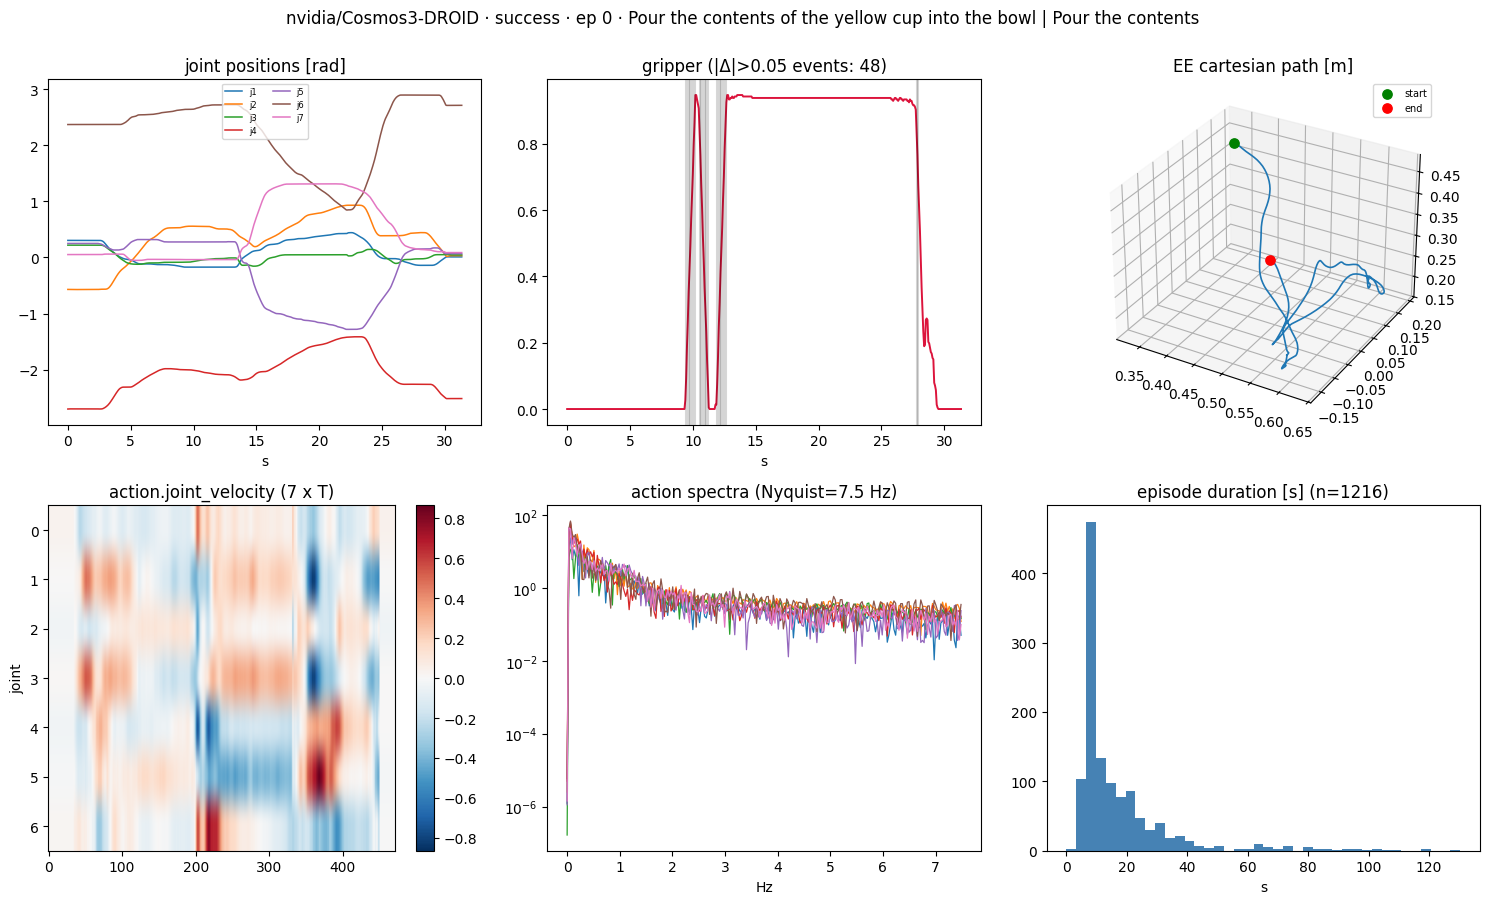


6. VIDEO: SEEK-BASED AV1 DECODE (no full download)
decoded (12, 160, 160, 3) from success/videos/observation.image.wrist_image_left/chunk-000/file-000.mp4


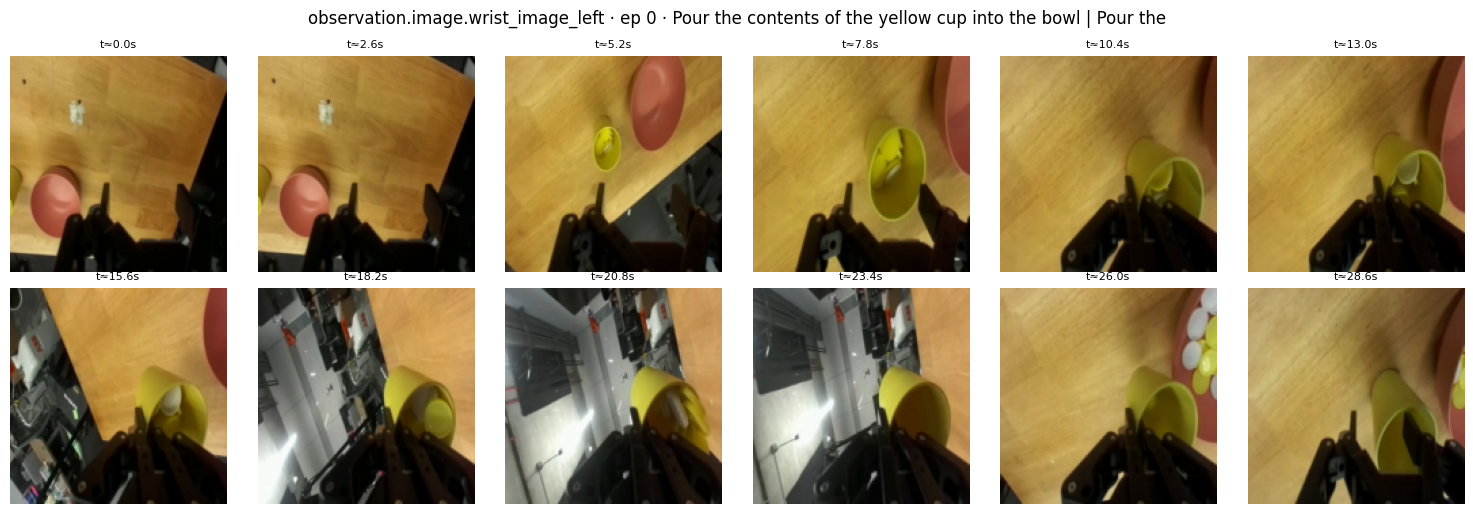


7. NORMALIZATION


stats.json:   0%|          | 0.00/34.4k [00:00<?, ?B/s]

using dataset-level stats from meta/stats.json

8. BUILDING TRAINING SET
   loaded 8/48 episodes
   loaded 16/48 episodes
   loaded 24/48 episodes
   loaded 32/48 episodes
   loaded 40/48 episodes
   loaded 48/48 episodes
loaded 48 episodes, 24,312 frames
   video ep 0: (200, 96, 96, 3)
   video ep 1: (200, 96, 96, 3)
   video ep 2: (200, 96, 96, 3)
   video ep 3: (200, 96, 96, 3)
   video ep 4: (200, 96, 96, 3)
   video ep 5: (200, 96, 96, 3)
vision enabled: True (6 episodes cached)
train windows=764 (4 eps)   val windows=382 (2 eps)

model params: 1.43 M  (vision=True)

9. TRAINING
epoch  1/12  train=0.67849  val=0.55124  (8.7s)
epoch  2/12  train=0.52185  val=0.45107  (6.9s)
epoch  3/12  train=0.44772  val=0.41966  (6.6s)
epoch  4/12  train=0.39109  val=0.41664  (6.1s)
epoch  5/12  train=0.36007  val=0.42939  (6.2s)
epoch  6/12  train=0.34057  val=0.43630  (6.5s)
epoch  7/12  train=0.32191  val=0.43571  (6.2s)
epoch  8/12  train=0.31523  val=0.43497  (6.4s)
epoch  9/12  train=0.3029

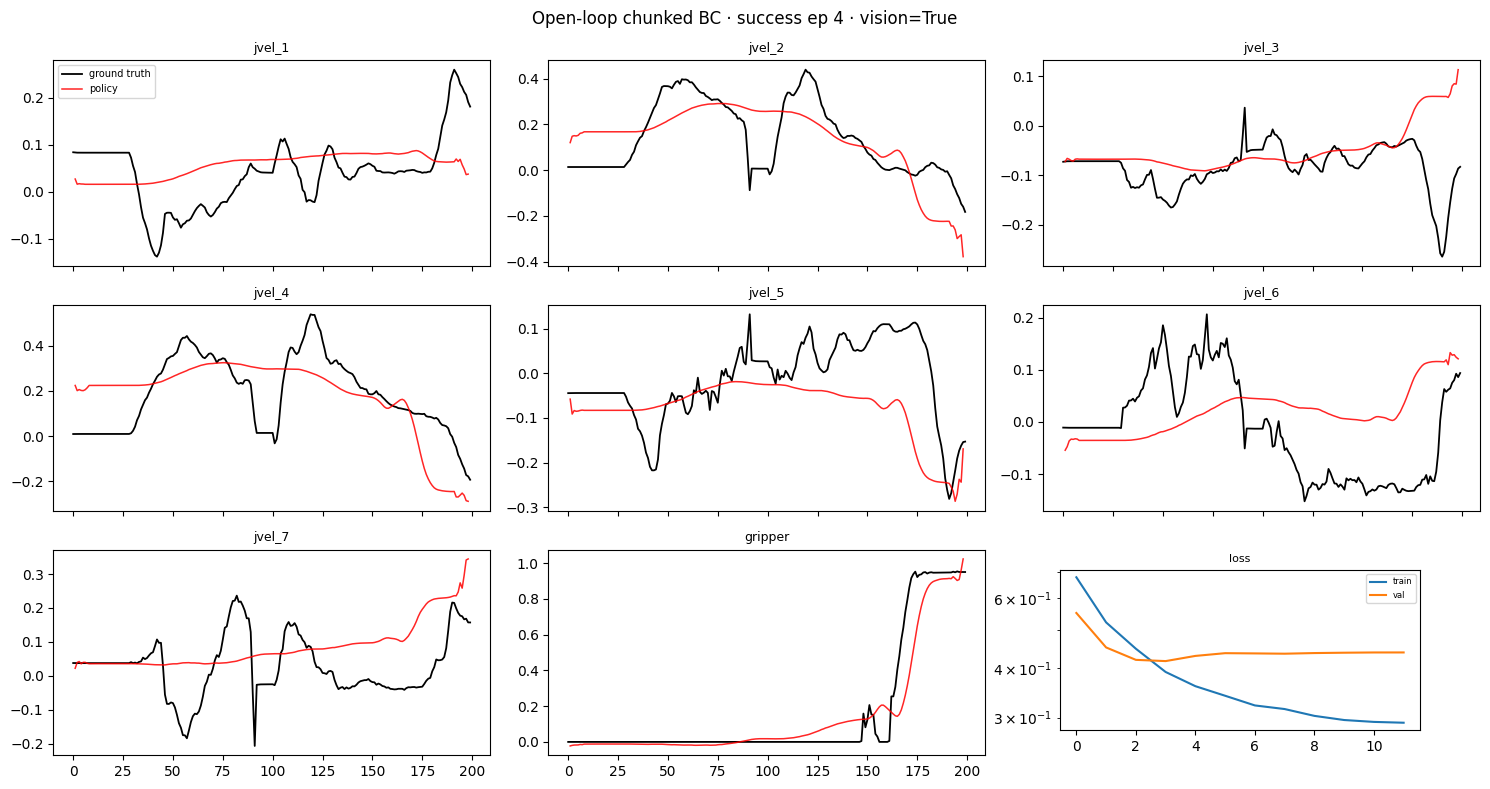


saved -> droid_chunk_policy.pt

DONE. Everything above streamed from a 707 GB repo; peak disk use ≈ a few hundred MB.

Scale-up levers
  · N_EPISODES / more shards      -> data_shards[1:], rebuild EP_BOUNDS per shard
  · ROOT="failure"                -> 14,268 negative episodes for success classifiers
  · VIDEO_KEY                     -> exterior_image_1_left / exterior_image_2_left
                                     (3 synced views: multi-view or view-randomisation)
  · language                      -> 53,086 task strings; add a text encoder for VLA-style
                                     conditioning instead of the state-only trunk
  · targets                       -> swap ACTION_USE to action.cartesian_velocity for
                                     end-effector control, or predict deltas
  · real training                 -> pip install lerobot; LeRobotDataset("<local>/success")
                                     once you have local disk (v3.0 native loader)


In [ ]:
print("\n" + "="*78 + "\n10. OPEN-LOOP ROLLOUT (temporal ensembling)\n" + "="*78)

@torch.no_grad()
def rollout(ep, m=0.1):
    d = EPISODES[ep]; T = len(d["state"])
    if USE_VISION: T = min(T, len(VIS_CACHE[ep]))
    acc = np.zeros((T, HORIZON, A_DIM), np.float32); cnt = np.zeros((T, HORIZON), np.float32)
    model.eval()
    for i in range(OBS_HISTORY-1, T-HORIZON):
        s = torch.from_numpy(((d["state"][i-OBS_HISTORY+1:i+1]-S_MEAN)/S_STD).ravel()
                             .astype(np.float32))[None].to(DEV)
        img = None
        if USE_VISION:
            img = torch.from_numpy((VIS_CACHE[ep][i].astype(np.float32)/255.)
                                   .transpose(2, 0, 1))[None].to(DEV)
        p = model(s, img)[0].float().cpu().numpy()*A_STD + A_MEAN
        for k in range(HORIZON):
            if i+k < T: acc[i+k, k] = p[k]; cnt[i+k, k] = math.exp(-m*k)
    w = cnt[..., None]; pred = (acc*w).sum(1) / np.maximum(w.sum(1), 1e-8)
    valid = cnt.sum(1) > 0
    return pred, d["action"][:T], valid

ep_eval = te_eps[0]
pred, gt, valid = rollout(ep_eval)
mse  = ((pred[valid]-gt[valid])**2).mean(0)
base = ((gt[valid].mean(0)-gt[valid])**2).mean(0)
names = [f"jvel_{i+1}" for i in range(7)] + ["gripper"]
print(f"episode {ep_eval} · task: {EPISODES[ep_eval]['task'][:70]}")
print(f"{'dim':<10}{'MSE':>12}{'mean-baseline':>16}{'R²':>10}")
for i, nm in enumerate(names[:A_DIM]):
    print(f"{nm:<10}{mse[i]:>12.5f}{base[i]:>16.5f}{1-mse[i]/max(base[i],1e-9):>10.3f}")
print(f"{'OVERALL':<10}{mse.mean():>12.5f}{base.mean():>16.5f}{1-mse.mean()/base.mean():>10.3f}")

fig, axs = plt.subplots(3, 3, figsize=(15, 8), sharex=True)
for i, ax in enumerate(axs.ravel()):
    if i >= A_DIM: ax.axis("off"); continue
    ax.plot(gt[:, i], "k", lw=1.3, label="ground truth")
    ax.plot(np.where(valid, pred[:, i], np.nan), "r", lw=1.1, alpha=.85, label="policy")
    ax.set_title(names[i], fontsize=9)
    if i == 0: ax.legend(fontsize=7)
axs.ravel()[-1].axis("off")
inset = fig.add_axes([0.71, 0.08, 0.24, 0.2])
inset.plot(hist["train"], label="train"); inset.plot(hist["val"], label="val")
inset.set_yscale("log"); inset.set_title("loss", fontsize=8); inset.legend(fontsize=6)
plt.suptitle(f"Open-loop chunked BC · {ROOT} ep {ep_eval} · vision={USE_VISION}")
plt.tight_layout(); plt.show()

torch.save({"model": model.state_dict(), "s_mean": S_MEAN, "s_std": S_STD,
            "a_mean": A_MEAN, "a_std": A_STD, "cfg": dict(
                state_keys=STATE_USE, action_keys=ACTION_USE, horizon=HORIZON,
                obs_history=OBS_HISTORY, vision=USE_VISION, root=ROOT)},
           "droid_chunk_policy.pt")
print("\nsaved -> droid_chunk_policy.pt")

print(f"""
{'='*78}
DONE. Everything above streamed from a 707 GB repo; peak disk use ≈ a few hundred MB.

Scale-up levers
  · N_EPISODES / more shards      -> data_shards[1:], rebuild EP_BOUNDS per shard
  · ROOT="failure"                -> 14,268 negative episodes for success classifiers
  · VIDEO_KEY                     -> exterior_image_1_left / exterior_image_2_left
                                     (3 synced views: multi-view or view-randomisation)
  · language                      -> 53,086 task strings; add a text encoder for VLA-style
                                     conditioning instead of the state-only trunk
  · targets                       -> swap ACTION_USE to action.cartesian_velocity for
                                     end-effector control, or predict deltas
  · real training                 -> pip install lerobot; LeRobotDataset("<local>/{ROOT}")
                                     once you have local disk (v3.0 native loader)
{'='*78}""")